Name: Mahmoud Faisal,
IMDB , Metacritic Data Analysis

Insall transformers AI library

Connect Jupyter notebook to MongoDB through Json file

In [1]:
import json

# Demonstration of how to load a file that contains secrets without accidentally leaking those secrets
with open('credentials.json') as f:
    creds = json.load(f)

    # If you want your data to be secure, don't print this variable out!
    # Jupyter will retain a cached version of any printed data and it can be
    # accidentally committed to version control.
    secret_key = creds['mongodb']

# We can safely print the length of the secret key. That won't leak any sensitive information.
print(f"My secret key is {len(secret_key)} characters in length.")

My secret key is 110 characters in length.


Fetch data from Monogo DB and connect Jupyter to Imdb database

In [2]:
from pymongo import MongoClient
import certifi
import pandas as pd
from datetime import datetime

client = MongoClient(creds["mongodb"])


# my Database on Mongo Campas is Imdb and i is capital
db = client["Imdb"]

#collection name is imdb small i
collection = db.list_collection_names()
print(collection)


['imdb2', 'Metacritic', 'IMDB_Pipeline_view']


Connect Jupyter to imdb and filter movies by release date by year 2000

In [3]:
from matplotlib import pyplot as plt
import re
import pandas as pd
from datetime import datetime

import pandas as pd

# Retrieve all records from a collection - this can be a large amount of data!
cursor = db["IMDB_Pipeline_view"].find()

# Convert this information into a Pandas dataframe
imdb = pd.DataFrame(cursor)

#clean null from gross_sales_new
gross_sales_new2_cleaned = imdb.dropna(subset=['gross_sales_new2'])


# Convert the release_date column to datetime
imdb['release_date'] = pd.to_datetime(imdb['release_date'], errors='coerce')

# Filter for rows where the release year is 2000
imdb_2000 = imdb[imdb['release_date'].dt.year == 2000]

columns_to_display = ['title', 'release_date', 'user_rating', 'budget_new',"gross_sales_new2"]

imdb_2000[columns_to_display].head()
#display(imdb_2000)



,title,release_date,user_rating,budget_new,gross_sales_new2
7001,Dr. T & the Women,2000-09-01,4,23000000,22844291.0
7002,The Filth and the Fury,2000-01-25,7,None,NaN
7003,"Just, Melvin: Just Evil",2000-01-08,7,500000,NaN
7004,Mohabbatein,2000-10-27,7,4000000,NaN
7005,Thirteen Days,2000-12-16,7,80000000,66579890.0


Connect Jupyter to Metacritic and filter movies by release date by year 2000

In [4]:
# Retrieve all records from a collection - this can be a large amount of data!
cursor2 = db["Metacritic"].find()

# Convert this information into a Pandas dataframe
metacritic = pd.DataFrame(cursor2)


# Convert the release_date column to datetime
metacritic['release_date'] = pd.to_datetime(metacritic['release_date'], errors='coerce')

# Filter for rows where the release year is 2000
metacritic_2000 = metacritic[metacritic['release_date'].dt.year == 2000]

# Display the filtered results
metacritic_2000.head()

,_id,movie_id,title,release_date,description,score,thumbnail
0,67364f526d467415bc2a2174,11257,High Fidelity,2000-03-31 08:00:00,"In this biting romantic comedy, Rob Gordon (Cu...",79,https://static.metacritic.com/images/products/...
1,67364f526d467415bc2a21b6,11323,The Cup,2000-01-28 08:00:00,World Cup fever has reached the Indian Himalay...,70,https://static.metacritic.com/images/products/...
2,67364f526d467415bc2a2167,11244,Paragraph 175,2000-09-13 07:00:00,"During World War II 100,000 German homosexual ...",85,https://static.metacritic.com/images/products/...
3,67364f526d467415bc2a2207,11404,Non-Stop,2000-11-10 08:00:00,The story of three losers brought together by ...,56,https://static.metacritic.com/images/products/...
6,67364f526d467415bc2a21d7,11356,Vénus beauté (institut),2000-10-27 07:00:00,This film takes us into this world of beauty a...,64,https://static.metacritic.com/images/products/...


Merging two data sets together

In [5]:
unified_view = pd.merge(imdb_2000, metacritic_2000, how="inner", on="title")

unified_view.head()

,_id_x,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,matching_certification,release_date_fixed,year,month,_id_y,movie_id,release_date_y,description,score,thumbnail
0,636afeb03bc31743d94b4aa0,None,"Paul Cook, Steve Jones, John Lydon, Glen Matlo...","TV-MA::(cable rating), R","FilmFour, Jersey Shore, Nitrate Films, Panacea...",Julien Temple,"Documentary, Biography, Music",None,236216,None,...,[ R],2000-01-25,2000,1,67364f526d467415bc2a216b,11248,2000-04-07 07:00:00,An English documentary by Julien Temple which ...,82,https://static.metacritic.com/images/products/...
1,636afc263bc31743d94b499a,"$80,000,000 (estimated)","Shawn Driscoll, Kevin Costner, Drake Cook, Luc...",PG-13,"New Line Cinema, Beacon Communications, Beacon...",Roger Donaldson,"Drama, History, Thriller","$66,579,890",146309,"$46,668, 29 Dec 2000",...,[],2000-12-16,2000,12,67364f526d467415bc2a21ca,11343,2000-12-25 08:00:00,A dramatization of what took place in the Whit...,67,https://static.metacritic.com/images/products/...
2,636afd453bc31743d94b4a0a,"$8,500,000 (estimated)","Billy Crudup, Bill Haugland, Nelson Landrieu, ...",R,"Polygram Filmed Entertainment, Egg Pictures, G...",Keith Gordon,"Drama, Mystery, Romance, Thriller",None,127349,"$150,422, 26 Mar 2000",...,[],2000-01-22,2000,1,67364f526d467415bc2a21f5,11386,2000-03-24 08:00:00,A lawyer (Crudup) running for Congress starts ...,59,https://static.metacritic.com/images/products/...
3,636afc8d3bc31743d94b49c1,"$80,000,000 (estimated)","Val Kilmer, Carrie-Anne Moss, Tom Sizemore, Be...",PG-13,"Warner Bros., Village Roadshow Pictures, NPV E...",Antony Hoffman,"Action, Sci-Fi, Thriller","$15,983,079",199753,"$8,721,296, 12 Nov 2000",...,[],2000-11-06,2000,11,67364f526d467415bc2a2282,11527,2000-11-10 08:00:00,Mission Commander Kate Bowman (Moss) is the pi...,34,https://static.metacritic.com/images/products/...
4,636afcde3bc31743d94b49e0,"$84,000,000 (estimated)","Eddie Murphy, Janet Jackson, Larry Miller, Joh...","TV-14::(DLS, TV Rating.), PG-13, Unrated","Universal Pictures, Imagine Entertainment, Sha...",Peter Segal,"Comedy, Romance, Sci-Fi","$166,339,890",144528,"$42,518,830, 30 Jul 2000",...,[ PG-13],2000-07-24,2000,7,67364f526d467415bc2a226f,11508,2000-07-28 07:00:00,A University Professor (Jackson) becomes the l...,38,https://static.metacritic.com/images/products/...


In [6]:
import statsmodels.formula.api

unified_view['budget_new']=pd.to_numeric(unified_view['budget_new'].replace('[\$,]','',regex = True),errors='coerce')
unified_view['opening_new']=pd.to_numeric(unified_view['opening_new'].replace('[\$,]','',regex = True),errors='coerce')

ols_model = statsmodels.formula.api.ols(
    formula= "gross_sales_new2 ~  user_rating +budget_new + opening_new +votes + runtime ",
    data= unified_view).fit()
print(ols_model.summary())


<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
C:\Users\sadek\AppData\Local\Temp\ipykernel_13908\3404377549.py:3: SyntaxWarning: invalid escape sequence '\$'
  unified_view['budget_new']=pd.to_numeric(unified_view['budget_new'].replace('[\$,]','',regex = True),errors='coerce')
C:\Users\sadek\AppData\Local\Temp\ipykernel_13908\3404377549.py:4: SyntaxWarning: invalid escape sequence '\$'
  unified_view['opening_new']=pd.to_numeric(unified_view['opening_new'].replace('[\$,]','',regex = True),errors='coerce')


                            OLS Regression Results                            
Dep. Variable:       gross_sales_new2   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     62.15
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           7.97e-24
Time:                        20:16:14   Log-Likelihood:                -1398.2
No. Observations:                  73   AIC:                             2808.
Df Residuals:                      67   BIC:                             2822.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1.653e+08   4.87e+07     -3.397      

In [7]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
text_to_analyze = "This movie was amazing!"
result = sentiment_pipeline(text_to_analyze)
print(result)

c:\Users\sadek\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[{'label': 'POSITIVE', 'score': 0.9998800754547119}]


Construct a sentiment pipeline

In [8]:
import transformers

MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
sentiment_task = transformers.pipeline("sentiment-analysis", model=MODEL,
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL, use_fast=False))


print(sentiment_task("covid is bad"))
print(sentiment_task("covid is good"))
print(sentiment_task("covid is neutral"))

[{'label': 'negative', 'score': 0.9503776431083679}]
[{'label': 'positive', 'score': 0.63665372133255}]
[{'label': 'neutral', 'score': 0.48918962478637695}]


Creating a sentiment function

In [9]:
def calculate_sentiment(text):
    if text is None :
        return 0
    sentiment = sentiment_task(text)
    if sentiment[0]['label']== 'negative':
        return 0 - sentiment[0]['score']-0.5
    elif sentiment[0]['label']== 'neutral':
        return sentiment[0]['score']-0.5
    elif sentiment[0]['label']== 'positive':
        return 1+ sentiment[0]['score']-0.5
print(calculate_sentiment("i came down with the flu and i'm feeling really sick"))

-1.405491292476654


Creating new columns in Pandas

In [10]:
sentiment_column = unified_view.apply(lambda row: calculate_sentiment(row.get('description')), axis = 1)
unified_view["sentiment"]= sentiment_column
unified_view.head()

,_id_x,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,release_date_fixed,year,month,_id_y,movie_id,release_date_y,description,score,thumbnail,sentiment
0,636afeb03bc31743d94b4aa0,None,"Paul Cook, Steve Jones, John Lydon, Glen Matlo...","TV-MA::(cable rating), R","FilmFour, Jersey Shore, Nitrate Films, Panacea...",Julien Temple,"Documentary, Biography, Music",None,236216,None,...,2000-01-25,2000,1,67364f526d467415bc2a216b,11248,2000-04-07 07:00:00,An English documentary by Julien Temple which ...,82,https://static.metacritic.com/images/products/...,0.161318
1,636afc263bc31743d94b499a,"$80,000,000 (estimated)","Shawn Driscoll, Kevin Costner, Drake Cook, Luc...",PG-13,"New Line Cinema, Beacon Communications, Beacon...",Roger Donaldson,"Drama, History, Thriller","$66,579,890",146309,"$46,668, 29 Dec 2000",...,2000-12-16,2000,12,67364f526d467415bc2a21ca,11343,2000-12-25 08:00:00,A dramatization of what took place in the Whit...,67,https://static.metacritic.com/images/products/...,0.187404
2,636afd453bc31743d94b4a0a,"$8,500,000 (estimated)","Billy Crudup, Bill Haugland, Nelson Landrieu, ...",R,"Polygram Filmed Entertainment, Egg Pictures, G...",Keith Gordon,"Drama, Mystery, Romance, Thriller",None,127349,"$150,422, 26 Mar 2000",...,2000-01-22,2000,1,67364f526d467415bc2a21f5,11386,2000-03-24 08:00:00,A lawyer (Crudup) running for Congress starts ...,59,https://static.metacritic.com/images/products/...,-1.310894
3,636afc8d3bc31743d94b49c1,"$80,000,000 (estimated)","Val Kilmer, Carrie-Anne Moss, Tom Sizemore, Be...",PG-13,"Warner Bros., Village Roadshow Pictures, NPV E...",Antony Hoffman,"Action, Sci-Fi, Thriller","$15,983,079",199753,"$8,721,296, 12 Nov 2000",...,2000-11-06,2000,11,67364f526d467415bc2a2282,11527,2000-11-10 08:00:00,Mission Commander Kate Bowman (Moss) is the pi...,34,https://static.metacritic.com/images/products/...,0.042648
4,636afcde3bc31743d94b49e0,"$84,000,000 (estimated)","Eddie Murphy, Janet Jackson, Larry Miller, Joh...","TV-14::(DLS, TV Rating.), PG-13, Unrated","Universal Pictures, Imagine Entertainment, Sha...",Peter Segal,"Comedy, Romance, Sci-Fi","$166,339,890",144528,"$42,518,830, 30 Jul 2000",...,2000-07-24,2000,7,67364f526d467415bc2a226f,11508,2000-07-28 07:00:00,A University Professor (Jackson) becomes the l...,38,https://static.metacritic.com/images/products/...,-0.119634


Creating View for Sentiment analysis

Text(0, 0.5, 'sentiment')

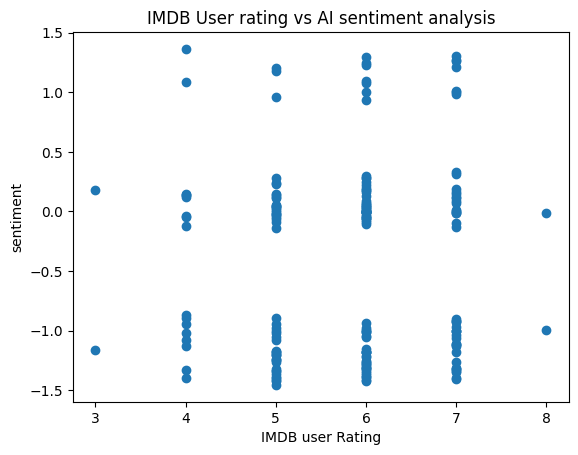

In [11]:
from matplotlib import pyplot as plt
plt.scatter(unified_view['user_rating'],unified_view['sentiment'])
plt.title('IMDB User rating vs AI sentiment analysis')
plt.xlabel('IMDB user Rating')
plt.ylabel('sentiment')

Most movies in 2000 got 6 out of 10 in user rating 

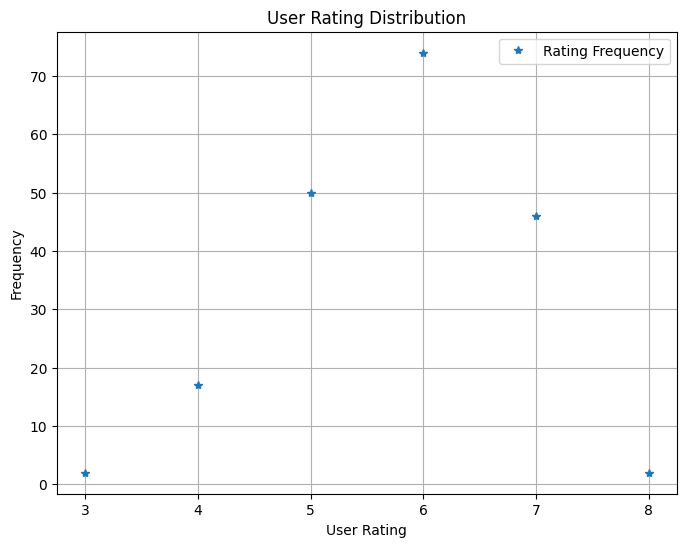

In [12]:
from matplotlib import pyplot as plt

# Group by user ratings and count their occurrences
rating_distribution = unified_view['user_rating'].value_counts().sort_index()

# Plot the frequency distribution
plt.figure(figsize=(8, 6))
plt.title('User Rating Distribution')
plt.xlabel('User Rating')
plt.ylabel('Frequency')
plt.plot(rating_distribution, '*', label='Rating Frequency')
plt.legend()
plt.grid(True)
plt.show()

Most of movies get 6 as a user rating

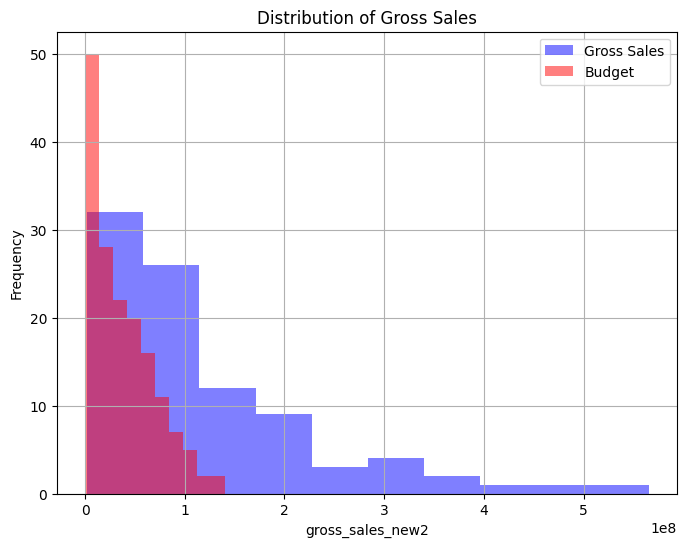

In [13]:
import matplotlib.pyplot as plt  
# Define the column to plot  
column = 'gross_sales_new2'  
  
# Create the histogram  
plt.figure(figsize=(8, 6))  
plt.hist(unified_view['gross_sales_new2'], bins=10, alpha=0.5, color='blue', label='Gross Sales')  
plt.hist(unified_view['budget_new'], bins=10, alpha=0.5, color='red', label='Budget')  
plt.legend()  
plt.xlabel(column)  
plt.ylabel('Frequency')  
plt.title('Distribution of Gross Sales')  
plt.grid(True)  
plt.show()


This code creates a histogram showing the distribution of gross sales for movies released in 2000. The x-axis represents the gross sales, and the y-axis represents the frequency of each bin